## Practice: Basic Artificial Neural Networks
Credits: this notebook belongs to [Practical DL](https://docs.google.com/forms/d/e/1FAIpQLScvrVtuwrHSlxWqHnLt1V-_7h2eON_mlRR6MUb3xEe5x9LuoA/viewform?usp=sf_link) course by Yandex School of Data Analysis.

We will start working with neural networks on the practice session. Your homework will be to finish the implementation of the layers.

Our goal is simple, yet an actual implementation may take some time :). We are going to write an Artificial Neural Network (almost) from scratch. The software design was heavily inspired by [PyTorch](http://pytorch.org) which is the main framework of our course

Speaking about the homework (once again, it will be really similar to this seminar), it requires sending **multiple** files, please do not forget to include all the files when sending to TA. The list of files:
- This notebook
- modules.ipynb with all blocks implemented (except maybe `Conv2d` and `MaxPool2d` layers implementation which are part of 'advanced' version of this homework)

In [58]:
%matplotlib inline
from time import time, sleep
import numpy as np
import matplotlib.pyplot as plt
from IPython import display

# Framework

Implement everything in `modules.ipynb`. Read all the comments thoughtfully to ease the pain. Please try not to change the prototypes.

Do not forget, that each module should return **AND** store `output` and `gradInput`.

The typical assumption is that `module.backward` is always executed after `module.forward`,
so `output` is stored, this would be useful for `SoftMax`.

### Tech note
Prefer using `np.multiply`, `np.add`, `np.divide`, `np.subtract` instead of `*`,`+`,`/`,`-` for better memory handling.

Example: suppose you allocated a variable

```
a = np.zeros(...)
```
So, instead of
```
a = b + c  # will be reallocated, GC needed to free
```
You can use:
```
np.add(b,c,out = a) # puts result in `a`
```

In [59]:
import os
import requests
import json
from urllib.parse import urlparse, parse_qs

filename = "modules.ipynb"

github_raw_url = "https://raw.githubusercontent.com/gammabox2020/ml-course-2023-homeworks/23f_basic/homeworks/hw08_nn_from_scratch/modules.ipynb"

if not os.path.exists(filename):
    print(f"'{filename}' не найден. Скачиваем с GitHub...")
    response = requests.get(github_raw_url)
    response.raise_for_status()  # выбросит исключение при HTTP-ошибке

    with open(filename, "wb") as f:
        f.write(response.content)

    print(f"Файл успешно скачан и сохранён как '{filename}'")
else:
    print(f"'{filename}' уже существует — скачивание не требуется.")

if os.path.exists(filename):
    py_filename = "modules.py"
    print(f"Конвертируем '{filename}' в '{py_filename}'...")

    with open(filename, 'r', encoding='utf-8') as f:
        nb = json.load(f)

    with open(py_filename, 'w', encoding='utf-8') as f:
        for cell in nb['cells']:
            if cell['cell_type'] == 'code':
                for line in cell['source']:
                    f.write(line)
                f.write('\n')

    print(f"'{py_filename}' успешно создан!")

'modules.ipynb' уже существует — скачивание не требуется.
Конвертируем 'modules.ipynb' в 'modules.py'...
'modules.py' успешно создан!


In [60]:
# (re-)load layers
# %run modules.ipynb

import sys
import importlib
import os
import shutil

# хочу что modules подгружался с диска каждый раз заново
if 'modules' in sys.modules:
    del sys.modules['modules']
# удалить кеш компиляции
if os.path.exists('__pycache__'):
    shutil.rmtree('__pycache__')

from modules import *


/content/modules.py:396: SyntaxWarning: invalid escape sequence '\g'
  Implements linear transform of input y = \gamma * x + \beta


# Toy example

Use this example to debug your code, start with logistic regression and then test other layers. You do not need to change anything here. This code is provided for you to test the layers. Also it is easy to use this code in MNIST task.

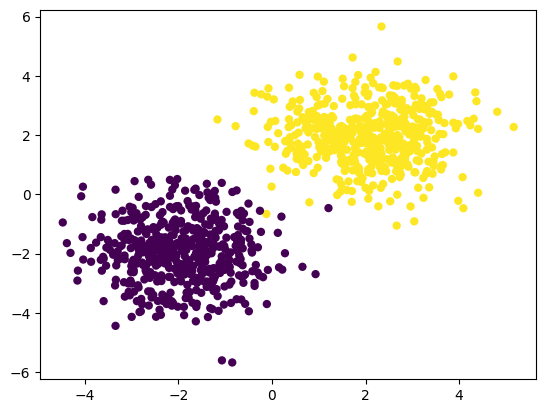

In [61]:
# Generate some data
N = 500

X1 = np.random.randn(N,2) + np.array([2,2])
X2 = np.random.randn(N,2) + np.array([-2,-2])

Y = np.concatenate([np.ones(N),np.zeros(N)])[:,None]
Y = np.hstack([Y, 1-Y])

X = np.vstack([X1,X2])
plt.scatter(X[:,0],X[:,1], c = Y[:,0], edgecolors= 'none')

Define a **logistic regression** for debugging.

In [62]:
net = Sequential()
net.add(Linear(2, 2))
net.add(LogSoftMax())

criterion = ClassNLLCriterion()

print(net)

# Test something like that then

# net = Sequential()
# net.add(Linear(2, 4))
# net.add(ReLU())
# net.add(Linear(4, 2))
# net.add(LogSoftMax())

Linear 2 -> 2
LogSoftMax



Start with batch_size = 1000 to make sure every step lowers the loss, then try stochastic version.

In [63]:
# Iptimizer params
optimizer_config = {'learning_rate' : 1e-1, 'momentum': 0.9}
optimizer_state = {}

# Looping params
n_epoch = 20
batch_size = 128

In [64]:
# batch generator
def get_batches(dataset, batch_size):
    X, Y = dataset
    n_samples = X.shape[0]

    # Shuffle at the start of epoch
    indices = np.arange(n_samples)
    np.random.shuffle(indices)

    for start in range(0, n_samples, batch_size):
        end = min(start + batch_size, n_samples)

        batch_idx = indices[start:end]

        yield X[batch_idx], Y[batch_idx]

### Train

Basic training loop. Examine it.

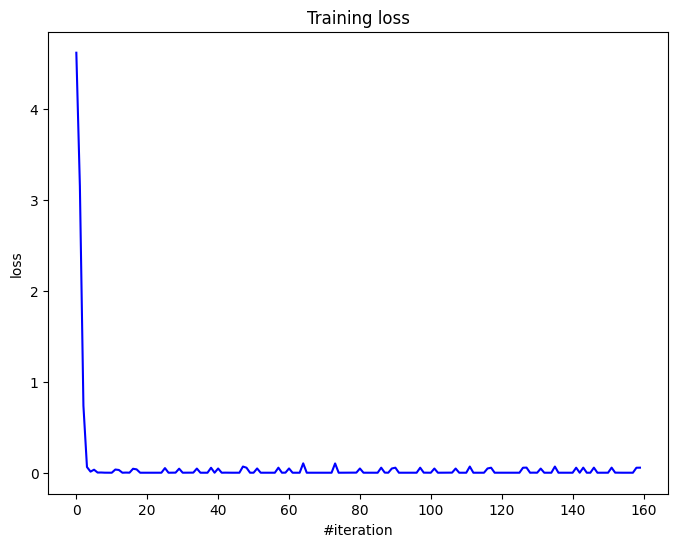

Current loss: 0.055543


In [65]:
loss_history = []

for i in range(n_epoch):
    for x_batch, y_batch in get_batches((X, Y), batch_size):

        net.zeroGradParameters()

        # Forward
        predictions = net.forward(x_batch)
        loss = criterion.forward(predictions, y_batch)

        # Backward
        dp = criterion.backward(predictions, y_batch)
        net.backward(x_batch, dp)

        # Update weights
        sgd_momentum(net.getParameters(),
                     net.getGradParameters(),
                     optimizer_config,
                     optimizer_state)

        loss_history.append(loss)

    # Visualize
    display.clear_output(wait=True)
    plt.figure(figsize=(8, 6))

    plt.title("Training loss")
    plt.xlabel("#iteration")
    plt.ylabel("loss")
    plt.plot(loss_history, 'b')
    plt.show()

    print('Current loss: %f' % loss)

# Digit classification

We are using old good [MNIST](http://yann.lecun.com/exdb/mnist/) as our dataset. It can be downloaded with the following file.

In [ ]:
#!wget https://raw.githubusercontent.com/girafe-ai/ml-course/23f_basic/homeworks/hw08_nn_from_scratch/mnist.py -nc
!wget https://raw.githubusercontent.com/gammabox2020/ml-course-2023-homeworks/23f_basic/homeworks/hw08_nn_from_scratch/mnist.py -nc

In [66]:
import sys
import importlib
import os
import shutil

# хочу что modules подгружался с диска каждый раз заново
if 'mnist' in sys.modules:
    del sys.modules['mnist']
# удалить кеш компиляции
if os.path.exists('__pycache__'):
    shutil.rmtree('__pycache__')

import mnist
X_train, y_train, X_val, y_val, X_test, y_test = mnist.load_dataset()

One-hot encode the labels first.

In [67]:
# Your code goes here. ################################################

def one_hot_encode(labels, num_classes=10):
    n_samples = labels.shape[0]
    one_hot = np.zeros((n_samples, num_classes))
    one_hot[np.arange(n_samples), labels] = 1
    return one_hot

y_train_oh = one_hot_encode(y_train)
y_val_oh = one_hot_encode(y_val)
y_test_oh = one_hot_encode(y_test)

print("y_train shape:", y_train.shape)        # (50000,)
print("y_train_oh shape:", y_train_oh.shape)  # (50000, 10)

print("y_train[0]:", y_train[0])
print("y_train_oh[0]:", y_train_oh[0])

print("перевести изображения в flatten")
X_train_flat = X_train.reshape(X_train.shape[0], -1)  # (50000, 784)
X_val_flat = X_val.reshape(X_val.shape[0], -1)        # (10000, 784)
X_test_flat = X_test.reshape(X_test.shape[0], -1)     # (10000, 784)

print("X_train_flat shape:", X_train_flat.shape)

y_train shape: (50000,)
y_train_oh shape: (50000, 10)
y_train[0]: 5
y_train_oh[0]: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
перевести изображения в flatten
X_train_flat shape: (50000, 784)


- **Compare** `ReLU`, `ELU`, `LeakyReLU`, `SoftPlus` activation functions.
You would better pick the best optimizer params for each of them, but it is overkill for now. Use an architecture of your choice for the comparison.
- **Try** inserting `BatchNormalization` (folowed by `ChannelwiseScaling`) between `Linear` module and activation functions.
- Plot the losses both from activation functions comparison and `BatchNormalization` comparison on one plot. Please find a scale (log?) when the lines are distinguishable, do not forget about naming the axes, the plot should be goodlooking.
- Plot the losses for two networks: one trained by momentum_sgd, another one trained by Adam. Which one performs better?
- Hint: good logloss for MNIST should be around 0.5.

In [68]:
# Your code goes here. ################################################

np.random.seed(900)

def create_network(activation_class, input_size=784, hidden_size=256, num_classes=10):
    """
    Linear -> Activation -> Linear -> Activation -> Linear -> LogSoftMax
    """
    net = Sequential()
    net.add(Linear(input_size, hidden_size))
    net.add(activation_class())
    net.add(Linear(hidden_size, hidden_size))
    net.add(activation_class())
    net.add(Linear(hidden_size, num_classes))
    net.add(LogSoftMax())
    return net

def train_network(net, criterion, X_train, y_train, X_val, y_val,
                  optimizer_func, optimizer_config,
                  n_epoch=20, batch_size=128):
    """
    train, возвращает историю loss
    """
    optimizer_state = {}
    train_loss_history = []
    val_loss_history = []

    for epoch in range(n_epoch):
        net.train()
        epoch_loss = []

        for x_batch, y_batch in get_batches((X_train, y_train), batch_size):
            net.zeroGradParameters()

            predictions = net.forward(x_batch)
            loss = criterion.forward(predictions, y_batch)

            dp = criterion.backward(predictions, y_batch)
            net.backward(x_batch, dp)

            # обновить веса
            optimizer_func(net.getParameters(),
                          net.getGradParameters(),
                          optimizer_config,
                          optimizer_state)

            epoch_loss.append(loss)

        train_loss_history.append(np.mean(epoch_loss))

        # валидация
        net.evaluate()
        val_predictions = net.forward(X_val)
        val_loss = criterion.forward(val_predictions, y_val)
        val_loss_history.append(val_loss)

        print(f"Epoch {epoch+1}/{n_epoch}, Train Loss: {train_loss_history[-1]:.4f}, Val Loss: {val_loss:.4f}")

    return train_loss_history, val_loss_history


In [ ]:
activations = {
    'ReLU': ReLU,
    'ELU': ELU,
    'LeakyReLU': LeakyReLU,
    'SoftPlus': SoftPlus
}

optimizer_config = {'learning_rate': 1e-2, 'momentum': 0.9}
criterion = ClassNLLCriterion()
n_epoch = 20

results = {}

for name, activation_class in activations.items():
    print(f"\n{'='*50}")
    print(f"Training with {name}")
    print('='*50)

    net = create_network(activation_class)
    train_loss, val_loss = train_network(
        net, criterion,
        X_train_flat, y_train_oh,
        X_val_flat, y_val_oh,
        sgd_momentum, optimizer_config,
        n_epoch=n_epoch
    )
    results[name] = {'train': train_loss, 'val': val_loss}

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for name, data in results.items():
    plt.plot(data['train'], label=name)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss - Activation Comparison')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
for name, data in results.items():
    plt.plot(data['val'], label=name)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Validation Loss - Activation Comparison')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


Training with ReLU
Epoch 1/20, Train Loss: 0.8255, Val Loss: 0.3091
Epoch 2/20, Train Loss: 0.2943, Val Loss: 0.2389
Epoch 3/20, Train Loss: 0.2268, Val Loss: 0.1934
Epoch 4/20, Train Loss: 0.1805, Val Loss: 0.1624
Epoch 5/20, Train Loss: 0.1479, Val Loss: 0.1329
Epoch 6/20, Train Loss: 0.1229, Val Loss: 0.1227
Epoch 7/20, Train Loss: 0.1036, Val Loss: 0.1064
Epoch 8/20, Train Loss: 0.0899, Val Loss: 0.1007
Epoch 9/20, Train Loss: 0.0777, Val Loss: 0.0970
Epoch 10/20, Train Loss: 0.0683, Val Loss: 0.0929
Epoch 11/20, Train Loss: 0.0609, Val Loss: 0.0868
Epoch 12/20, Train Loss: 0.0529, Val Loss: 0.0987
Epoch 13/20, Train Loss: 0.0484, Val Loss: 0.0868
Epoch 14/20, Train Loss: 0.0424, Val Loss: 0.0793
Epoch 15/20, Train Loss: 0.0379, Val Loss: 0.0793
Epoch 16/20, Train Loss: 0.0343, Val Loss: 0.0747
Epoch 17/20, Train Loss: 0.0300, Val Loss: 0.0750
Epoch 18/20, Train Loss: 0.0267, Val Loss: 0.0749
Epoch 19/20, Train Loss: 0.0245, Val Loss: 0.0735
Epoch 20/20, Train Loss: 0.0215, Val Lo

Write your personal opinion on the activation functions, think about computation times too. Does `BatchNormalization` help?

In [ ]:
# Your answer goes here. ################################################

**Finally**, use all your knowledge to build a super cool model on this dataset. Use **dropout** to prevent overfitting, play with **learning rate decay**. You can use **data augmentation** such as rotations, translations to boost your score. Use your knowledge and imagination to train a model. Don't forget to call `training()` and `evaluate()` methods to set desired behaviour of `BatchNormalization` and `Dropout` layers.

In [ ]:
# Your code goes here. ################################################

Print here your accuracy on test set. It should be around 90%.

In [ ]:
# Your answer goes here. ################################################

### Comparing with PyTorch implementation
The last (and maybe the easiest step after compared to the previous tasks: build a network with the same architecture as above now with PyTorch.

You can refer to the `week0_09` or `Lab3_part2` notebooks for hints.

__Good Luck!__

In [ ]:
# Your beautiful code here.